This notebook is dedicated to EDA (exploratory data analysis). It is meant to find hidden relationships before we start handling the main problem and solution.

In [1]:
#Adding Imports and setup

import os, sys, json, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from dateutil import parser as dateparser
from sklearn.model_selection import train_test_split

In [2]:
# Make plots a bit nicer
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [3]:
#Create Paths
project_root = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = project_root / "data"

true_data_path = data_dir / "True.csv"
fake_data_path = data_dir / "Fake.csv"

true_data_path, fake_data_path, project_root


(PosixPath('/Users/karinahernandez/accenture-ai-studio-fall2025/data/True.csv'),
 PosixPath('/Users/karinahernandez/accenture-ai-studio-fall2025/data/Fake.csv'),
 PosixPath('/Users/karinahernandez/accenture-ai-studio-fall2025'))

In [4]:
#Load datasets
true_df = pd.read_csv(true_data_path)
fake_df = pd.read_csv(fake_data_path)

print("true shape:", true_df.shape)
print("fake shape:", fake_df.shape)

display(true_df.head(3))
display(fake_df.head(3))


true shape: (21417, 4)
fake shape: (23481, 4)


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"


Slightly more Fake articles than True ones.

In [5]:
#Adding labels and combining datasets
true_df = true_df.copy()
true_df["target"] = 1
true_df["source_tag"] = "true_csv"

fake_df = fake_df.copy()
fake_df["target"] = 0
fake_df["source_tag"] = "fake_csv"

df = pd.concat([true_df, fake_df], ignore_index=True)
print("combined shape:", df.shape)
df.sample(3, random_state=58)

combined shape: (44898, 6)


,title,text,subject,date,target,source_tag
3905,"With Obamacare vote, House Republicans free to...",WASHINGTON (Reuters) - The Republican-controll...,politicsNews,"May 5, 2017",1,true_csv
23776,The Vacationer-In-Chief Was Asked To Grade Hi...,Amateur president Donald Trump s first thirty ...,News,"February 28, 2017",0,fake_csv
11113,North Carolina's voter ID law goes on trial,"WINSTON-SALEM, N.C. (Reuters) - Minority voter...",politicsNews,"January 25, 2016",1,true_csv


Datasets are now combined into 1 huge data set with a new column known as "target" that refers to what is True or Fake.

In [6]:
# Missingness
missing = df.isna().mean().sort_values(ascending=False)
display(missing.head(20))


title         0.0
text          0.0
subject       0.0
date          0.0
target        0.0
source_tag    0.0
dtype: float64

No missing values found.

In [7]:
import re

def normalize_date_string(s: str) -> str:
    s = str(s).replace("\xa0", " ")
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r",(\S)", r", \1", s)   # ensure space after comma
    return s

def parse_date_series(s: pd.Series) -> pd.Series:
    s_norm = s.astype(str).apply(normalize_date_string)
    # URLs -> NaT
    is_url = s_norm.str.contains(r"https?://", case=False, na=False)
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    # fast parse first
    fast = pd.to_datetime(s_norm[~is_url], errors="coerce")
    out.loc[~is_url] = fast
    # fallback with dateutil for remaining nulls
    mask = out.isna() & (~is_url)
    if mask.any():
        def safe_parse(x):
            try: return dateparser.parse(x)
            except Exception: return pd.NaT
        out.loc[mask] = s_norm.loc[mask].apply(safe_parse)
    return out

# --- 2) Parse dates separately for each file (so we can see which one is failing)
true_df["date"] = parse_date_series(true_df["date"])
fake_df["date"] = parse_date_series(fake_df["date"])

print("NaT in TRUE:", true_df["date"].isna().sum(), "of", len(true_df))
print("NaT in FAKE:", fake_df["date"].isna().sum(), "of", len(fake_df))

# --- 3) Combine cleanly, recompute helper features
df = pd.concat([true_df, fake_df], ignore_index=True)
df["target"] = df["target"].astype(int)

# sanity on totals
print("\nTotals by target in df:")
print(df["target"].value_counts(dropna=False))

# --- 4) Build a seasonality-only view (drop rows lacking a usable date)
df_seasonal = df.dropna(subset=["date"]).copy()

# seasonality parts
df_seasonal["year"]     = df_seasonal["date"].dt.year
df_seasonal["month"]    = df_seasonal["date"].dt.to_period("M")
df_seasonal["dow_name"] = df_seasonal["date"].dt.day_name()

print("\nAfter dropping NaT dates:")
print(df_seasonal["target"].value_counts(dropna=False))
print("\nCounts per year x class:")
print(pd.crosstab(df_seasonal["year"], df_seasonal["target"]).fillna(0))

NaT in TRUE: 0 of 21417
NaT in FAKE: 10 of 23481

Totals by target in df:
target
0    23481
1    21417
Name: count, dtype: int64

After dropping NaT dates:
target
0    23471
1    21417
Name: count, dtype: int64

Counts per year x class:
target      0      1
year                
2015     2479      0
2016    11754   4716
2017     9203  16701
2018       35      0


In [8]:
df.head()

,title,text,subject,date,target,source_tag
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31,1,true_csv
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29,1,true_csv
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31,1,true_csv
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30,1,true_csv
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29,1,true_csv


In [9]:
#Quick text features for EDA: title and text lengths and words
df["title_len"] = df["title"].astype(str).str.len()
df["text_len"]  = df["text"].astype(str).str.len()
df["title_words"] = df["title"].astype(str).str.split().str.len()
df["text_words"]  = df["text"].astype(str).str.split().str.len()


In [10]:
df.head()

,title,text,subject,date,target,source_tag,title_len,text_len,title_words,text_words
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31,1,true_csv,64,4659,10,749
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29,1,true_csv,64,4077,9,624
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31,1,true_csv,60,2789,10,457
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30,1,true_csv,59,2461,9,376
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29,1,true_csv,69,5204,11,852


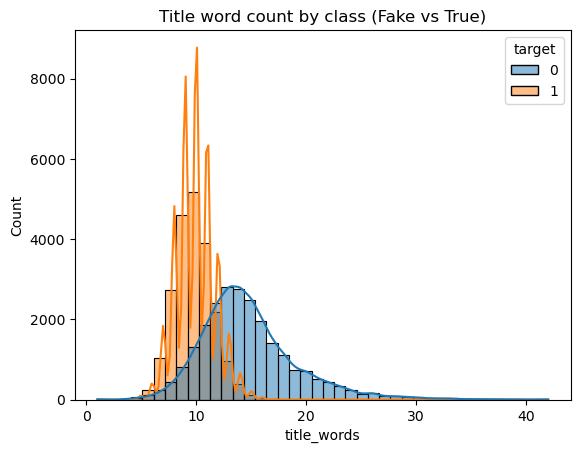

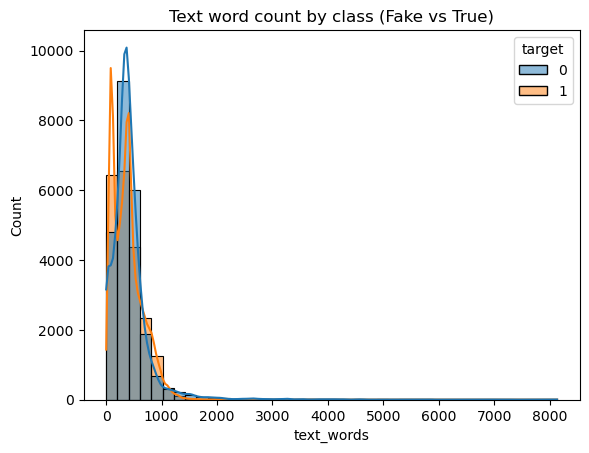

In [11]:
#Simple visuals of connection between Target and title/text word counts
import seaborn as sns

sns.histplot(data=df, x="title_words", hue="target", bins=40, kde=True)
plt.title("Title word count by class (Fake vs True)")
plt.show()

sns.histplot(data=df, x="text_words", hue="target", bins=40, kde=True)
plt.title("Text word count by class (Fake vs True)")
plt.show()


In [12]:
#Leakage & drift checks
print("Subject by class:")
display(df.groupby(["target","subject"]).size().unstack(fill_value=0))

# Correlation with label for numeric features
print("\nCorrelations with target:")
display(df[["target","title_len","text_len","title_words","text_words"]].corr(numeric_only=True)["target"].sort_values(ascending=False))


Subject by class:


subject,Government News,Middle-east,News,US_News,left-news,politics,politicsNews,worldnews
target,,,,,,,,
0,1570,778,9050,783,4459,6841,0,0
1,0,0,0,0,0,0,11272,10145



Correlations with target:


target         1.000000
text_len      -0.037747
text_words    -0.053405
title_words   -0.580489
title_len     -0.581159
Name: target, dtype: float64

Table suggests that we cannot go based on subject since it immediately detects fake or true news. We will drop this column since it is a major leak issue.

Correlations and graphs also show longer titles are more likely to be Fake. However, it is hard to tell much from text words.

In [13]:
#Drop Subject column
df = df.drop(columns=["subject"])

# Drop duplicates
df = df.drop_duplicates(subset=["text"]).dropna(subset=["title","text","target"])

# Combine text fields
df["all_text"] = (df["title"].astype(str) + " " + df["text"].astype(str)).str.strip()

#Meta data columns
meta_cols = ["title_words","text_words","title_len","text_len"]

In [14]:
df.head()

,title,text,date,target,source_tag,title_len,text_len,title_words,text_words,all_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,2017-12-31,1,true_csv,64,4659,10,749,"As U.S. budget fight looms, Republicans flip t..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,2017-12-29,1,true_csv,64,4077,9,624,U.S. military to accept transgender recruits o...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,2017-12-31,1,true_csv,60,2789,10,457,Senior U.S. Republican senator: 'Let Mr. Muell...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,2017-12-30,1,true_csv,59,2461,9,376,FBI Russia probe helped by Australian diplomat...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,2017-12-29,1,true_csv,69,5204,11,852,Trump wants Postal Service to charge 'much mor...


The following will be testing Seasonality in Dates. In other words, are the seasons/dates of these articles strong indicators in what is true or false.

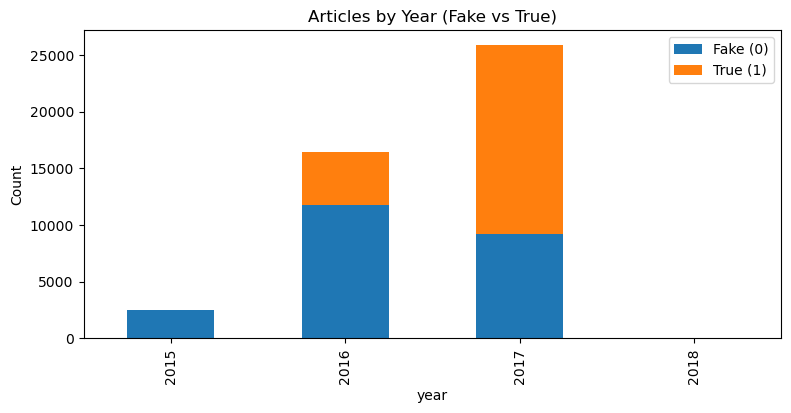

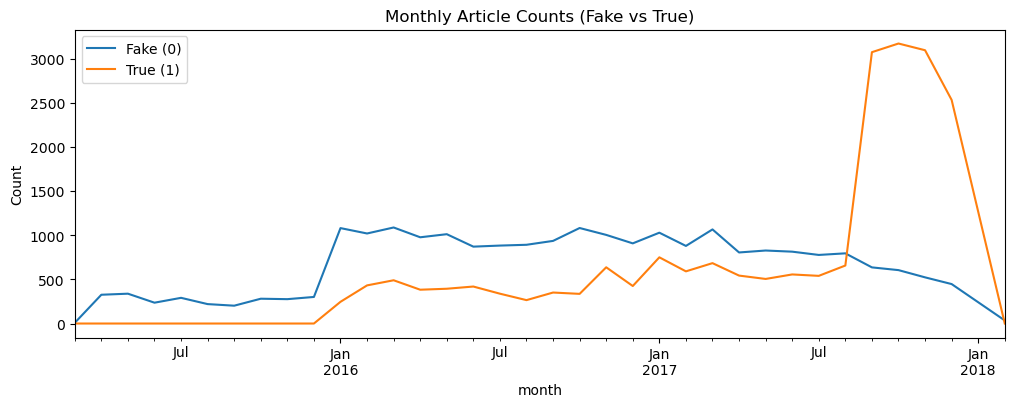

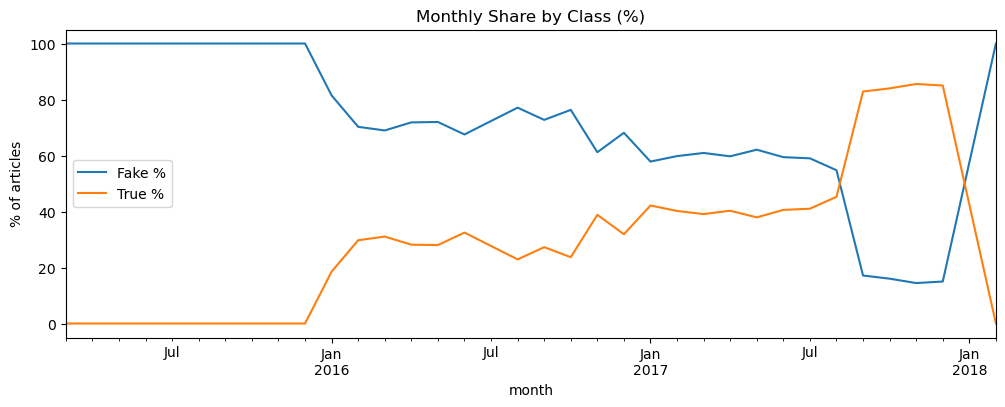

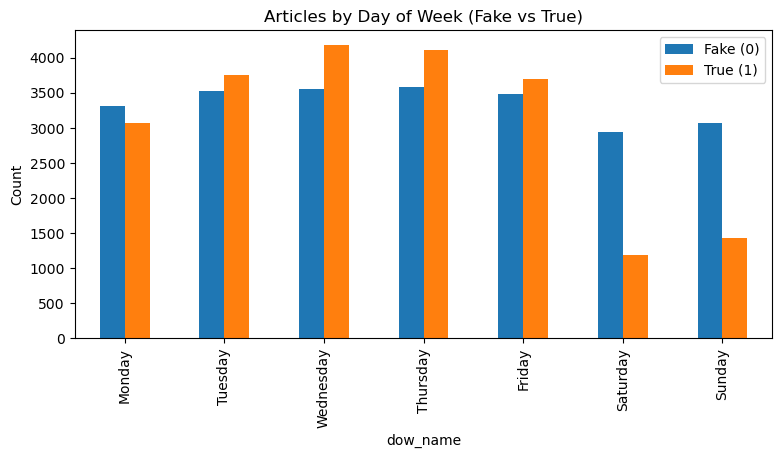

In [19]:
#Yearly
yearly = df_seasonal.groupby(["year","target"]).size().unstack(fill_value=0)

ax = yearly.plot(kind="bar", stacked=True, figsize=(9,4),
                 title="Articles by Year (Fake vs True)")
ax.set_ylabel("Count")
ax.legend(["Fake (0)", "True (1)"])
plt.show()

#Monthly counts: number of fake and true articles per month
monthly = df_seasonal.groupby([df_seasonal["month"], "target"]).size().unstack(fill_value=0)

ax = monthly.plot(figsize=(12,4), title="Monthly Article Counts (Fake vs True)")
ax.set_ylabel("Count")
ax.legend(["Fake (0)", "True (1)"])
plt.show()

#Monthly % share: Percentage of true or fake articles per month
monthly_pct = (monthly.div(monthly.sum(axis=1), axis=0) * 100).fillna(0)

ax = monthly_pct.plot(figsize=(12,4), title="Monthly Share by Class (%)")
ax.set_ylabel("% of articles")
ax.legend(["Fake %", "True %"])
plt.show()

#Day of week counts
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = df_seasonal.groupby([df_seasonal["dow_name"], "target"]).size().unstack(fill_value=0).reindex(order)

ax = dow.plot(kind="bar", figsize=(9,4), title="Articles by Day of Week (Fake vs True)")
ax.set_ylabel("Count")
ax.legend(["Fake (0)", "True (1)"])
plt.show()




Findings:
- True articles seem to be from 2016 and 2017. This is not a good parameter to judge off since that is specific to the database data.
- Usually more fake articles than true during the months. We see an increase of true articles near the end of 2017 but this could be due to data distribution.
- Significant count of fake articles come out on the weekends compared to true. Otherwise, usually an even mix on the weekdays.

Testing for Punctuation

In [20]:
# ---- make sure we're on the cleaned frame
df_seasonal = df_seasonal.copy()

# Title counts
df_seasonal["title_excl"]   = df_seasonal["title"].astype(str).str.count("!")
df_seasonal["title_qmark"]  = df_seasonal["title"].astype(str).str.count(r"\?")
df_seasonal["title_period"] = df_seasonal["title"].astype(str).str.count(r"\.")
df_seasonal["title_comma"]  = df_seasonal["title"].astype(str).str.count(",")

# Body counts
df_seasonal["text_excl"]    = df_seasonal["text"].astype(str).str.count("!")
df_seasonal["text_qmark"]   = df_seasonal["text"].astype(str).str.count(r"\?")
df_seasonal["text_period"]  = df_seasonal["text"].astype(str).str.count(r"\.")
df_seasonal["text_comma"]   = df_seasonal["text"].astype(str).str.count(",")

# Per-word ratios (robust to length)
def n_words(s): 
    return max(1, len(str(s).split()))

df_seasonal["title_excl_per_word"]  = df_seasonal.apply(lambda r: r["title_excl"]/n_words(r["title"]), axis=1)
df_seasonal["title_qmark_per_word"] = df_seasonal.apply(lambda r: r["title_qmark"]/n_words(r["title"]), axis=1)
df_seasonal["text_excl_per_word"]   = df_seasonal.apply(lambda r: r["text_excl"]/n_words(r["text"]), axis=1)
df_seasonal["text_qmark_per_word"]  = df_seasonal.apply(lambda r: r["text_qmark"]/n_words(r["text"]), axis=1)

# normalize target to {0,1}
df_seasonal["target"] = (
    df_seasonal["target"].astype(str).str.strip()
      .replace({"0":0,"1":1,"False":0,"True":1}).astype(int)
)


/var/folders/0z/zbxcnm2d34gczctbpxjqyppc0000gn/T/ipykernel_81515/2018663365.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"0":0,"1":1,"False":0,"True":1}).astype(int)


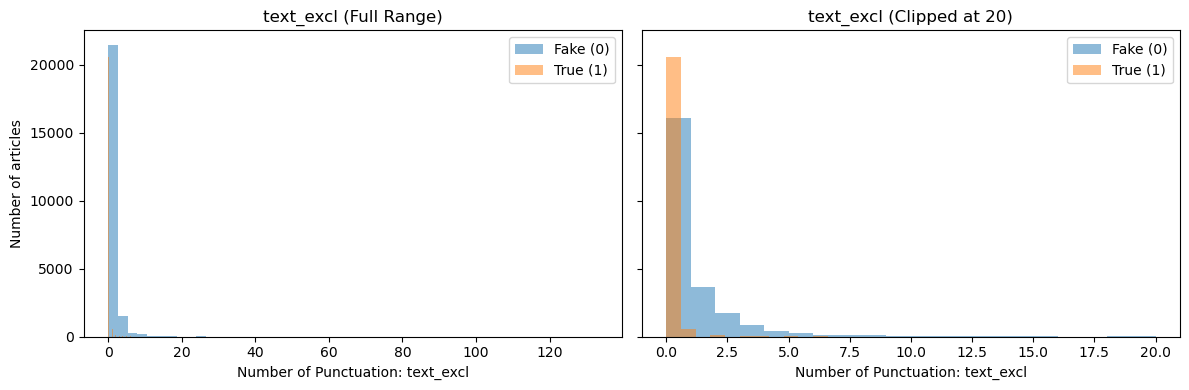

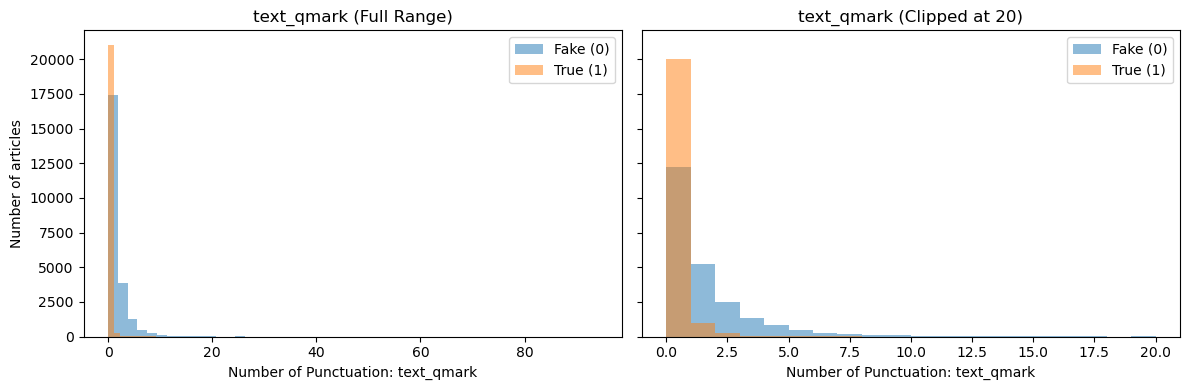

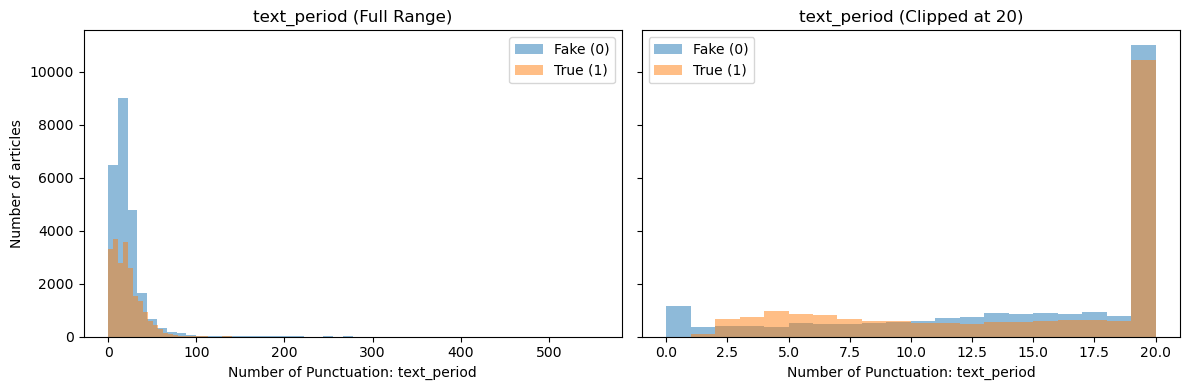

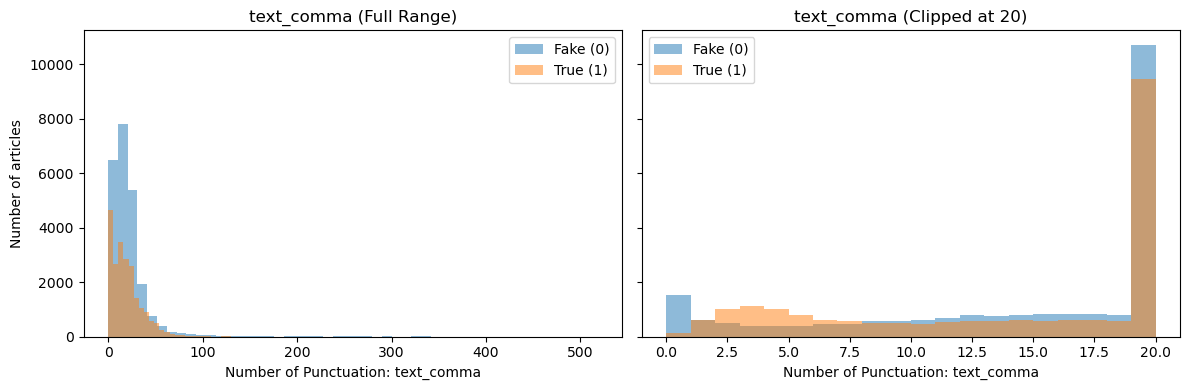

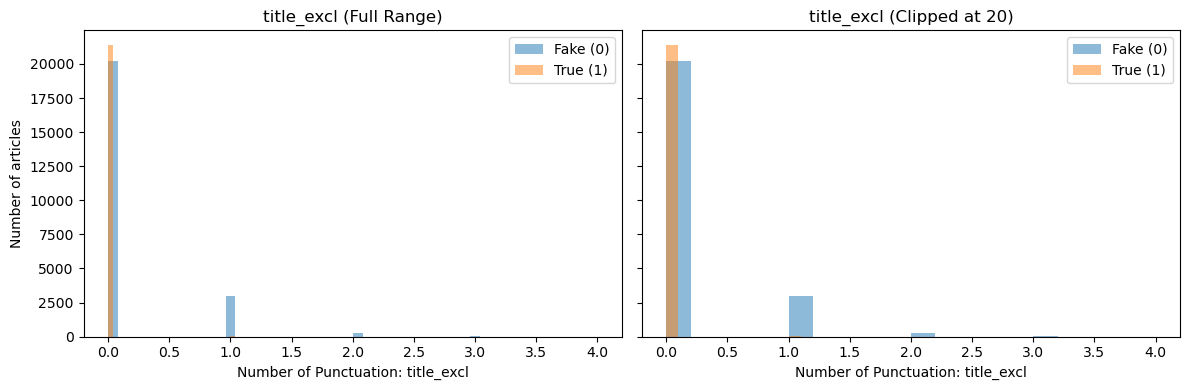

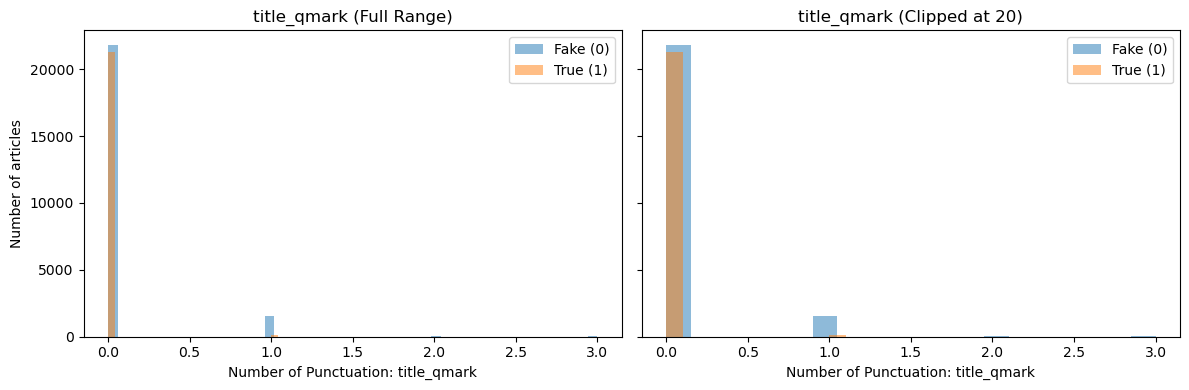

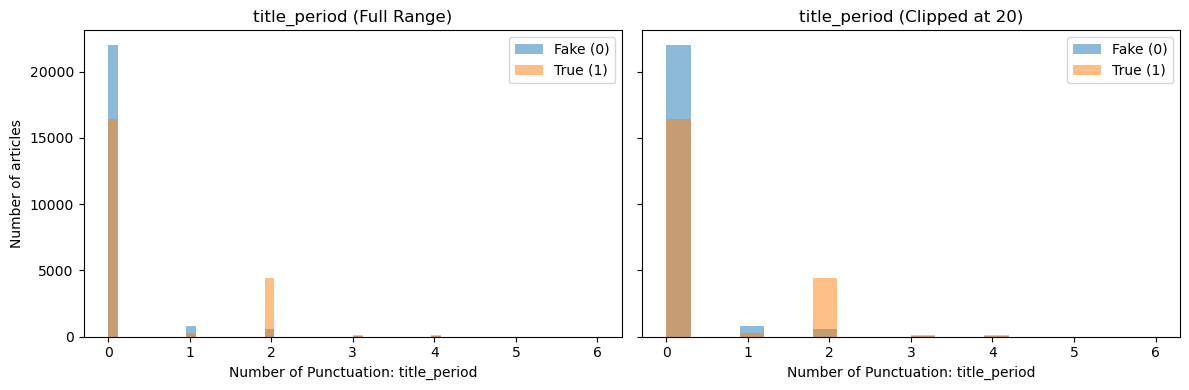

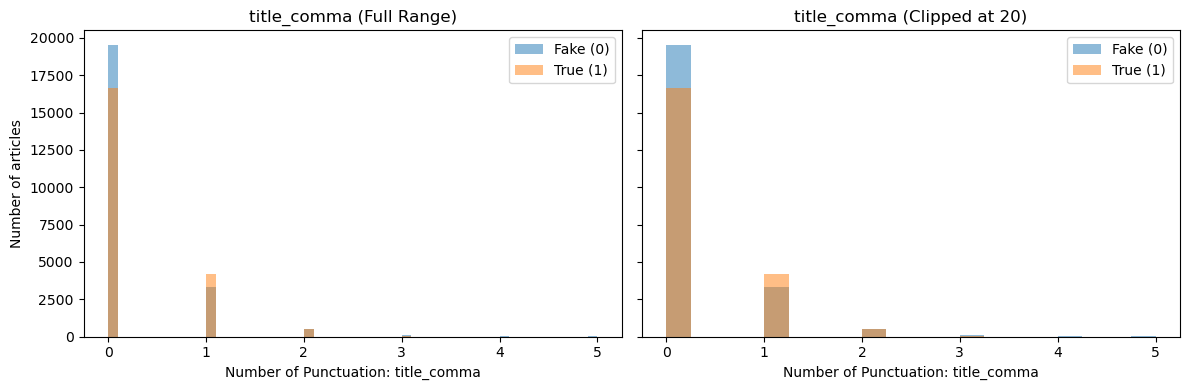

        text_excl                    text_qmark                   text_period                     text_comma         \
             mean median    std  max       mean median    std max        mean median     std  max       mean median   
target                                                                                                                
Fake(0)     0.723    0.0  1.920  133      1.206    0.0  2.284  94      20.913   18.0  20.146  555     20.970   17.0   
True(1)     0.062    0.0  0.418   12      0.101    0.0  0.631  57      20.983   18.0  15.972  282     19.393   16.0   

                     title_excl                   title_qmark                   title_period                    \
            std  max       mean median    std max        mean median    std max         mean median    std max   
target                                                                                                           
Fake(0)  23.444  518      0.154    0.0  0.401   4       0.074 

In [21]:
punct_cols = ["text_excl","text_qmark","text_period","text_comma",
              "title_excl","title_qmark","title_period","title_comma"]

present = [c for c in punct_cols if c in df_seasonal.columns]
if not present:
    print("No punctuation columns found to plot.")
else:
    for col in present:
        fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

        # Left: full range (unclipped)
        for t, lab, color in [(0,"Fake (0)","tab:blue"), (1,"True (1)","tab:orange")]:
            vals = df_seasonal.loc[df_seasonal["target"]==t, col].dropna()
            axes[0].hist(vals, bins=50, alpha=0.5, label=lab, color=color)
        axes[0].set_title(f"{col} (Full Range)")
        axes[0].set_xlabel(f"Number of Punctuation: {col}"); axes[0].set_ylabel("Number of articles"); axes[0].legend()

        # Right: clipped at 20 (anything >20 shown as 20)
        for t, lab, color in [(0,"Fake (0)","tab:blue"), (1,"True (1)","tab:orange")]:
            vals = df_seasonal.loc[df_seasonal["target"]==t, col].clip(upper=20).dropna()
            axes[1].hist(vals, bins=20, alpha=0.5, label=lab, color=color)
        axes[1].set_title(f"{col} (Clipped at 20)")
        axes[1].set_xlabel(f"Number of Punctuation: {col}"); axes[0].set_ylabel("Number of articles"); axes[1].legend()

        plt.tight_layout()
        plt.show()


#Summary
summary = (
    df_seasonal
    .groupby("target")[present]
    .agg(["mean","median","std","max"])
    .round(3)
    .rename(index={0:"Fake(0)",1:"True(1)"})
)
print(summary)


Findings:
    Title:
        Exclamation marks (!) on titles are associated with Fake News but I would further analyze
        Question marks (?) on titles are associated with Fake News but I would further analyze
    Text:
        Multiple exclamation marks (!) correlated with Fake News
        Multiple question marks (?) correlated with Fake News
        No periods are a sign of Fake news


Looking into outliers...

         text_words   title_words
count  44888.000000  44888.000000
mean     405.371191     12.456024
std      351.254129      4.108378
min        0.000000      3.000000
25%      203.000000     10.000000
50%      362.000000     11.000000
75%      513.000000     14.000000
max     8135.000000     42.000000
Text outliers: 1678
Title outliers: 2244


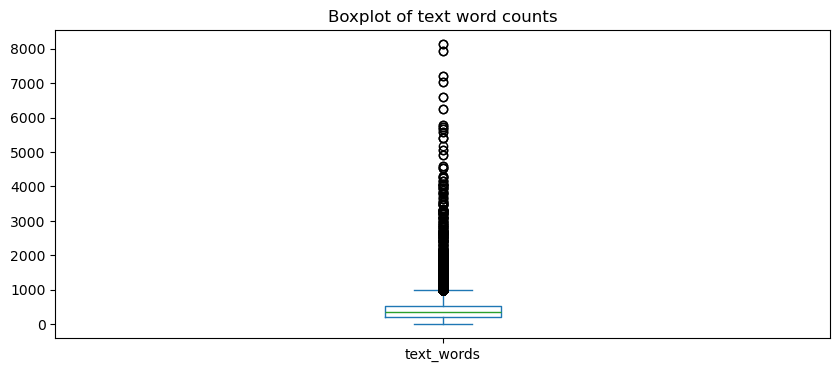

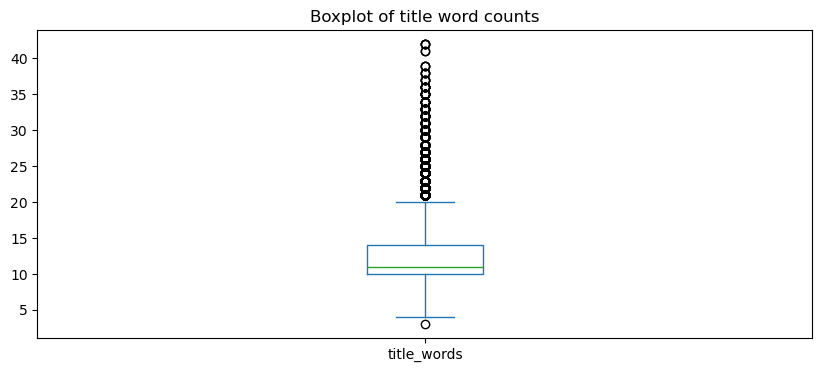

In [22]:
# Word counts for body text and title
df_seasonal["text_words"] = df_seasonal["text"].astype(str).apply(lambda x: len(x.split()))
df_seasonal["title_words"] = df_seasonal["title"].astype(str).apply(lambda x: len(x.split()))

# Quick sanity check
print(df_seasonal[["text_words","title_words"]].describe())


# Example for text_words
Q1 = df_seasonal["text_words"].quantile(0.25)
Q3 = df_seasonal["text_words"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_text = df_seasonal[(df_seasonal["text_words"] < lower) | (df_seasonal["text_words"] > upper)]
print("Text outliers:", outliers_text.shape[0])

# Example for title_words
Q1 = df_seasonal["title_words"].quantile(0.25)
Q3 = df_seasonal["title_words"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_title = df_seasonal[(df_seasonal["title_words"] < lower) | (df_seasonal["title_words"] > upper)]
print("Title outliers:", outliers_title.shape[0])


outliers_text[["title","text_words","target"]].head()
outliers_title[["title","title_words","target"]].head()

plt.figure(figsize=(10,4))
df_seasonal["text_words"].plot(kind="box")
plt.title("Boxplot of text word counts")
plt.show()

plt.figure(figsize=(10,4))
df_seasonal["title_words"].plot(kind="box")
plt.title("Boxplot of title word counts")
plt.show()


Beginning Feature Engineering: TF-IDF

In [42]:
#Train test split

# Create all_text column by combining title + text
df_seasonal["all_text"] = df_seasonal["title"].astype(str) + " " + df_seasonal["text"].astype(str)
df_seasonal["title_len"] = df_seasonal["title"].str.len()
df_seasonal["text_len"] = df_seasonal["text"].str.len()


meta_data_tfidf = [
    "title_excl","title_qmark","title_period","title_comma",
    "text_excl","text_qmark","text_period","text_comma",
    "title_excl_per_word","title_qmark_per_word",
    "text_excl_per_word","text_qmark_per_word",
    "title_words","text_words", "title_len", "text_len"
]

X = df_seasonal[["all_text"] + meta_data_tfidf]
y = df_seasonal["target"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((35910, 17), (8978, 17))

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Text + numeric preprocessors
text_vec = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),    # unigrams + bigrams
    max_features=100_000,
    min_df=2
)

preprocess = ColumnTransformer(
    transformers=[
        ("tfidf", text_vec, "all_text"),
        ("num",   StandardScaler(with_mean=False), meta_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

clf = LogisticRegression(
    max_iter=1000,
    solver="liblinear"
)

pipe = Pipeline([
    ("prep", preprocess),
    ("clf",  clf),
])

pipe


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=100000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'all_text'),
                                                 ('num',
                                                  StandardScaler(with_mean=False),
                                                  ['title_words', 'text_words',
                                                   'title_len',
                                                   'text_len'])])),
                ('clf', LogisticRegression(max_iter=1000, solver='liblinear'))])

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
cm


              precision    recall  f1-score   support

           0      0.994     0.980     0.987      4694
           1      0.979     0.994     0.986      4284

    accuracy                          0.987      8978
   macro avg      0.987     0.987     0.987      8978
weighted avg      0.987     0.987     0.987      8978

ROC-AUC: 0.9987240599975256


array([[4602,   92],
       [  26, 4258]])

Only 118 = 92+26 mistakes in total. This is extremely well which could suggest data leakage. 

In [47]:
# Get feature names for tfidf part
tfidf = pipe.named_steps["prep"].named_transformers_["tfidf"]
tfidf_vocab = tfidf.get_feature_names_out()
n_tfidf = len(tfidf_vocab)

# Coefs come from the final LR over [tfidf | scaled meta]
coefs = pipe.named_steps["clf"].coef_.ravel()

tfidf_coefs = coefs[:n_tfidf]
top_true_idx  = np.argsort(tfidf_coefs)[-25:][::-1]   # highest positive → True(1)
top_fake_idx  = np.argsort(tfidf_coefs)[:25]          # most negative → Fake(0)

print("\nTop tokens predicting TRUE (1):")
for i in top_true_idx:
    print(f"{tfidf_vocab[i]:<25}  {tfidf_coefs[i]:.4f}")

print("\nTop tokens predicting FAKE (0):")
for i in top_fake_idx:
    print(f"{tfidf_vocab[i]:<25}  {tfidf_coefs[i]:.4f}")



Top tokens predicting TRUE (1):
reuters                    18.1273
said                       17.7383
washington reuters         7.4963
president donald           4.6099
wednesday                  4.5562
washington                 4.4720
thursday                   4.1286
minister                   4.0269
tuesday                    3.9955
republican                 3.7769
friday                     3.7742
reuters president          3.6640
monday                     3.5845
nov                        3.0308
spokesman                  2.9542
told                       2.7497
presidential               2.7437
democratic                 2.7106
edt                        2.7006
government                 2.6968
moscow                     2.5745
comment                    2.4865
britain                    2.4594
told reuters               2.4512
election                   2.4470

Top tokens predicting FAKE (0):
video                      -8.2333
image                      -5.6610
just        

Positive correlation means likely to be correlated to True News and anything negative is associated with Fake News. I would look into getting trying the model without "reuters" and "said".

In [48]:
#Make a cleaned text column
BAD_TOKENS = {"reuters", "said"}
pattern = re.compile(r"\b(" + "|".join(map(re.escape, BAD_TOKENS)) + r")\b", flags=re.IGNORECASE)

def remove_bad_tokens(s: str) -> str:
    if not isinstance(s, str):
        return ""
    return pattern.sub("", s)

df_seasonal["all_text_clean"] = df_seasonal["all_text"].apply(remove_bad_tokens)

#The rest is creating a TD-IDF

text_vec = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),
    max_features=100_000,
    min_df=2,
    max_df=0.9,
)

preprocess = ColumnTransformer(
    transformers=[
        ("tfidf", text_vec, "all_text_clean"),  # ← use the cleaned column
        ("num",   StandardScaler(with_mean=False), meta_data_tfidf),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

clf = LogisticRegression(max_iter=1000, solver="liblinear")

pipe2 = Pipeline([
    ("prep", preprocess),
    ("clf",  clf),
])

pipe2

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_df=0.9,
                                                                  max_features=100000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'all_text_clean'),
                                                 ('num',
                                                  StandardScaler(with_mean=False),
                                                  ['title_excl', 'title_qmark',
                                                   'title_period',
                                                   'title_comma', 'text_excl',
                                                   'text_qmark', 'text_period',
                                                   'text_comma',
                                                   'title_excl_per_word',
                                                   'title_qmark_per_word',
                                                   'text_excl_per_word',
                                                   'text_qmark_per_word',
                                                   'title_words', 'text_words',
                                                   'title_len',
                                                   'text_len'])])),
                ('clf', LogisticRegression(max_iter=1000, solver='liblinear'))])

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X1 = df_seasonal[["all_text_clean"] + meta_data_tfidf]
y = df_seasonal["target"].astype(int)

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y, test_size=0.20, stratify=y, random_state=42
)

pipe2.fit(X_train1, y_train1)
y_pred = pipe2.predict(X_test1)
y_prob = pipe2.predict_proba(X_test1)[:,1]

print(classification_report(y_test1, y_pred, digits=3))
print("ROC-AUC:", roc_auc_score(y_test1, y_prob))

cm2 = confusion_matrix(y_test1, y_pred)
cm2


              precision    recall  f1-score   support

           0      0.994     0.976     0.985      4694
           1      0.974     0.993     0.984      4284

    accuracy                          0.984      8978
   macro avg      0.984     0.985     0.984      8978
weighted avg      0.985     0.984     0.984      8978

ROC-AUC: 0.9981735628493692


array([[4582,  112],
       [  28, 4256]])

- Accuracy droppped (0.987 -> 0.984)
- Model misses a few more fake
- ROC-AUC stayed around the same

Accuracy and ROC-AUC scores would've dropped more significantly if "reuters" and "said" would've been more legit signals of truthfulness. I would say, at this point, it is same to assume these words caused data leakage.

In [52]:
# Get feature names for tfidf part
tfidf = pipe2.named_steps["prep"].named_transformers_["tfidf"]
tfidf_vocab = tfidf.get_feature_names_out()
n_tfidf = len(tfidf_vocab)

# Coefs come from the final LR over [tfidf | scaled meta]
coefs = pipe2.named_steps["clf"].coef_.ravel()

tfidf_coefs = coefs[:n_tfidf]
top_true_idx  = np.argsort(tfidf_coefs)[-25:][::-1]   # highest positive → True(1)
top_fake_idx  = np.argsort(tfidf_coefs)[:25]          # most negative → Fake(0)

print("\nTop tokens predicting TRUE (1):")
for i in top_true_idx:
    print(f"{tfidf_vocab[i]:<25}  {tfidf_coefs[i]:.4f}")

print("\nTop tokens predicting FAKE (0):")
for i in top_fake_idx:
    print(f"{tfidf_vocab[i]:<25}  {tfidf_coefs[i]:.4f}")



Top tokens predicting TRUE (1):
washington                 5.1096
wednesday                  5.0898
president donald           4.9728
thursday                   4.6207
tuesday                    4.4053
friday                     4.3432
minister                   4.1794
monday                     4.0526
republican                 3.9274
spokesman                  3.4190
edt                        3.4055
washington president       3.1947
told                       3.0449
nov                        2.9893
comment                    2.9301
presidential               2.8737
government                 2.8281
statement                  2.7660
britain                    2.7391
democratic                 2.7064
party                      2.6439
london                     2.6051
moscow                     2.5183
eu                         2.4962
parliament                 2.4327

Top tokens predicting FAKE (0):
video                      -8.3448
image                      -7.2853
featured image